# Data Preprocessing
## Breast Cancer Wisconsin (Diagnostic) Dataset — Stage 2

This notebook prepares the dataset for modelling, acting on what the
**data-understanding** stage (`01_data_understanding.ipynb`) established:

| Finding (Stage 1) | Consequence for preprocessing |
|---|---|
| 569 rows, 0 missing, 0 duplicates | **No imputation / de-duplication** required |
| All 30 features numeric (`float64`) | **No categorical encoding** required |
| Features on very different scales | **Feature scaling (standardisation)** is essential |
| Moderate class imbalance (~63/37) | **Stratified** split & cross-validation |
| Strong multicollinearity (|r| > 0.9 pairs) | Explore **PCA / feature selection** |

**Golden rule applied throughout:** every transformation is **fit on the
training set only** and then applied to the test set, to prevent
**data leakage**.

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
import joblib

pd.set_option("display.max_columns", 40)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

print("Libraries loaded. random_state =", RANDOM_STATE)

Libraries loaded. random_state = 42


## 2. Load the Dataset

In [2]:
from pathlib import Path

csv_path = Path("breast_cancer_wisconsin.csv")
if csv_path.exists():
    df = pd.read_csv(csv_path)
else:
    from sklearn.datasets import load_breast_cancer
    ds = load_breast_cancer(as_frame=True)
    df = ds.frame.copy()
    df["diagnosis"] = df["target"].map({0: "malignant", 1: "benign"})

print("Shape:", df.shape)
df.head()

Shape: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## 3. Re-verify Data Quality (quick gate)

Preprocessing should never assume the upstream stage — we re-check the two
quality gates before transforming anything.

In [3]:
print("Missing values total :", int(df.isnull().sum().sum()))
print("Duplicate rows       :", int(df.duplicated().sum()))
assert df.isnull().sum().sum() == 0, "Unexpected missing values!"
assert df.duplicated().sum() == 0, "Unexpected duplicate rows!"
print("Quality gate passed -> no imputation / de-duplication needed.")

Missing values total : 0
Duplicate rows       : 0
Quality gate passed -> no imputation / de-duplication needed.


## 4. Separate Features (X) and Target (y)

In [4]:
feature_cols = [c for c in df.columns if c not in ("target", "diagnosis")]

X = df[feature_cols].copy()          # 30 numeric features
y = df["target"].copy()              # 0 = malignant, 1 = benign

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts().rename({0: "malignant (0)", 1: "benign (1)"}))

X shape: (569, 30)
y shape: (569,)

Target distribution:
target
benign (1)       357
malignant (0)    212
Name: count, dtype: int64


## 5. Stratified Train / Test Split

We hold out **20%** for testing. `stratify=y` preserves the ~63/37 class
ratio in both splits — important given the moderate imbalance. The split is
done **before** scaling so the scaler never sees test data.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")
print("\nClass proportions preserved (stratified):")
prop = pd.DataFrame({
    "train": y_train.value_counts(normalize=True).round(3),
    "test":  y_test.value_counts(normalize=True).round(3),
    "full":  y.value_counts(normalize=True).round(3),
}).rename(index={0: "malignant", 1: "benign"})
print(prop)

Train: 455 rows | Test: 114 rows

Class proportions preserved (stratified):
           train   test   full
target                        
benign     0.626  0.632  0.627
malignant  0.374  0.368  0.373


## 6. Feature Scaling (Standardisation)

Stage 1 showed features spanning very different ranges (`area` in the
thousands vs `smoothness` < 1). We apply **`StandardScaler`** (z-score:
mean 0, std 1). Crucially the scaler is **fit on the training data only**,
then used to transform both train and test.

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on TRAIN
X_test_scaled  = scaler.transform(X_test)        # transform only on TEST

# Back to DataFrames for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=feature_cols, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=feature_cols, index=X_test.index)

print("After scaling — training set (should be ~0 mean, ~1 std):")
check = pd.DataFrame({
    "mean": X_train_scaled.mean().round(3),
    "std":  X_train_scaled.std().round(3),
}).head(6)
print(check)

After scaling — training set (should be ~0 mean, ~1 std):
                  mean    std
mean radius       -0.0  1.001
mean texture       0.0  1.001
mean perimeter    -0.0  1.001
mean area         -0.0  1.001
mean smoothness    0.0  1.001
mean compactness  -0.0  1.001


**Leakage check.** The *test* set will not be perfectly mean-0 / std-1, and
that is correct — it is scaled using the **training** statistics, exactly as a
deployed model would treat unseen data.

In [7]:
print("Test set after scaling (NOT exactly 0/1 — uses TRAIN stats, as intended):")
print(pd.DataFrame({
    "mean": X_test_scaled.mean().round(3),
    "std":  X_test_scaled.std().round(3),
}).head(6))

Test set after scaling (NOT exactly 0/1 — uses TRAIN stats, as intended):
                   mean    std
mean radius       0.086  1.038
mean texture      0.048  0.880
mean perimeter    0.085  1.033
mean area         0.092  1.100
mean smoothness   0.072  1.213
mean compactness  0.044  0.936


### 6.1 Visualise the effect of scaling

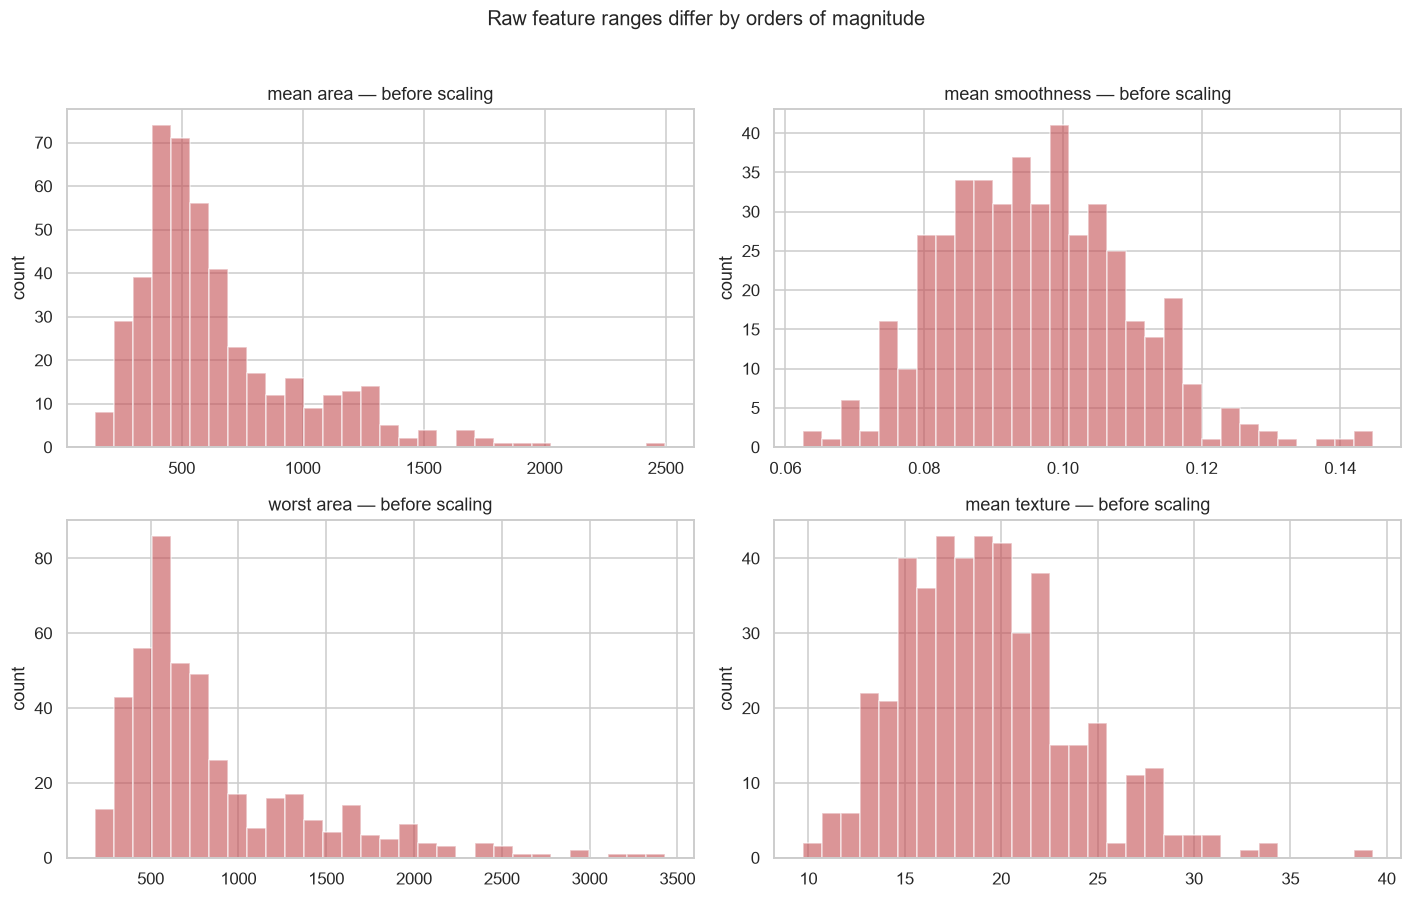

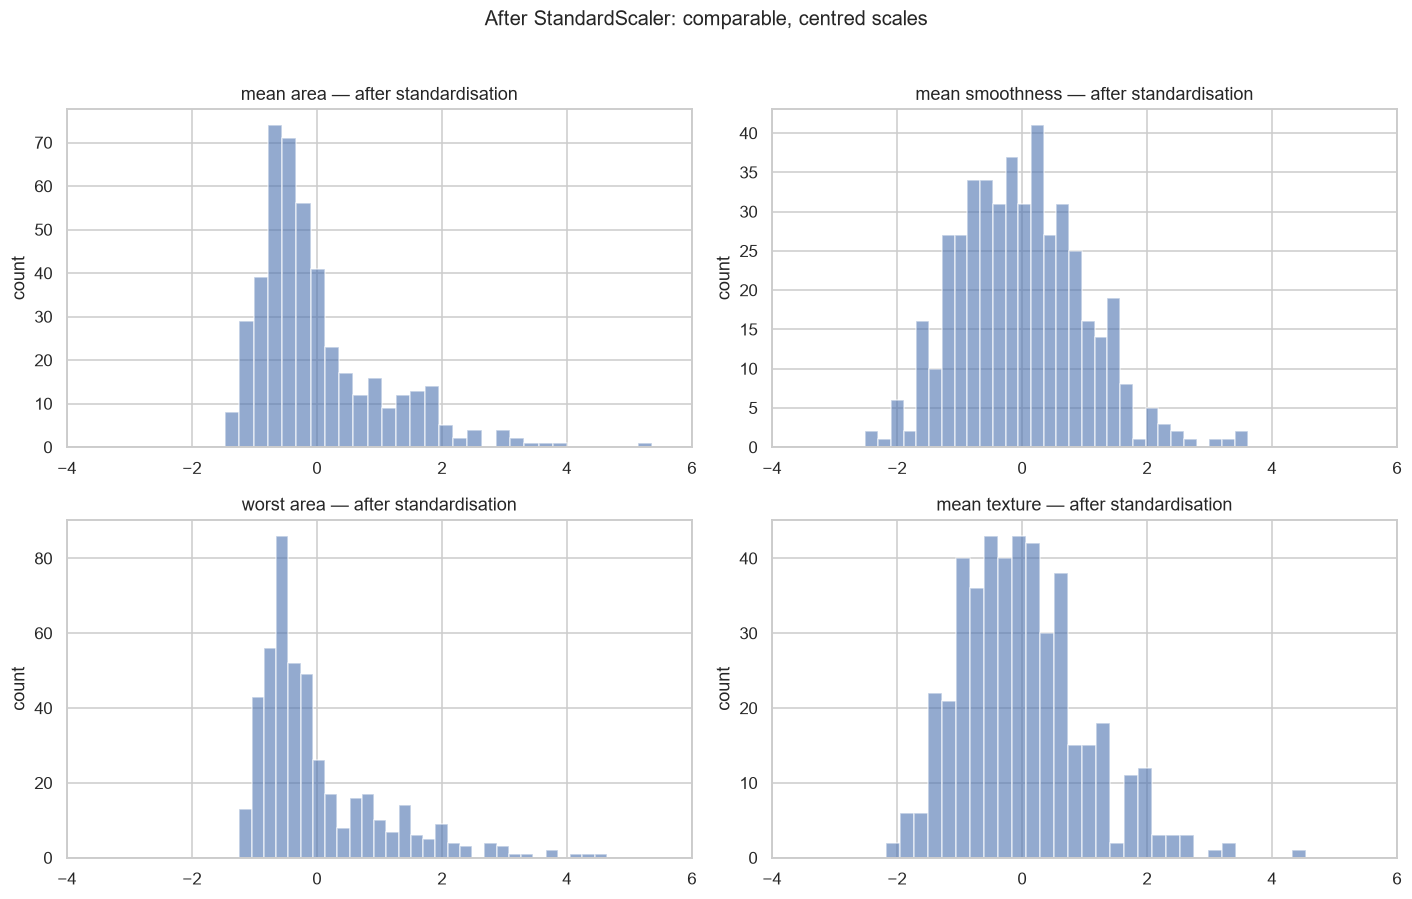

In [8]:
demo = ["mean area", "mean smoothness", "worst area", "mean texture"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat in zip(axes.ravel(), demo):
    ax.hist(X_train[feat], bins=30, alpha=0.6, label="raw", color="#C44E52")
    ax.set_title(f"{feat} — before scaling")
    ax.set_ylabel("count")
plt.suptitle("Raw feature ranges differ by orders of magnitude", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/06_before_scaling.png", dpi=130, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, feat in zip(axes.ravel(), demo):
    ax.hist(X_train_scaled[feat], bins=30, alpha=0.6, label="scaled", color="#4C72B0")
    ax.set_title(f"{feat} — after standardisation")
    ax.set_ylabel("count")
    ax.set_xlim(-4, 6)
plt.suptitle("After StandardScaler: comparable, centred scales", y=1.02, fontsize=13)
plt.tight_layout()
plt.savefig("figures/07_after_scaling.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Multicollinearity — Optional Dimensionality Reduction (PCA)

Stage 1 found many feature pairs with |correlation| > 0.9. **PCA** is one way
to compress that redundancy into a smaller set of uncorrelated components.
PCA **requires scaled input**, which we now have. We fit PCA on the *training*
data only.

> This is exploratory: whether to actually use PCA is a modelling choice. Here
> we quantify how many components capture most of the variance.

In [9]:
pca_full = PCA(random_state=RANDOM_STATE).fit(X_train_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

for thresh in (0.90, 0.95, 0.99):
    k = int(np.argmax(cum_var >= thresh) + 1)
    print(f"{int(thresh*100)}% of variance is captured by {k} components (of 30)")

90% of variance is captured by 7 components (of 30)
95% of variance is captured by 10 components (of 30)
99% of variance is captured by 17 components (of 30)


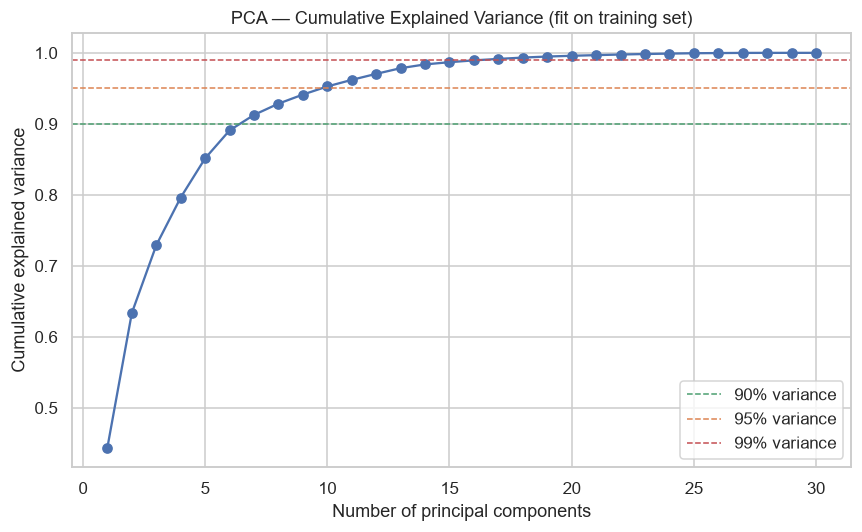

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cum_var) + 1), cum_var, marker="o", color="#4C72B0")
for thresh, c in [(0.90, "#4C9F70"), (0.95, "#DD8452"), (0.99, "#C44E52")]:
    plt.axhline(thresh, ls="--", color=c, lw=1, label=f"{int(thresh*100)}% variance")
plt.title("PCA — Cumulative Explained Variance (fit on training set)")
plt.xlabel("Number of principal components")
plt.ylabel("Cumulative explained variance")
plt.legend()
plt.tight_layout()
plt.savefig("figures/08_pca_scree.png", dpi=130, bbox_inches="tight")
plt.show()

**Observation.** The 30 correlated features can be compressed dramatically —
roughly **10 components explain ~95%** of the variance. This confirms the
redundancy seen in Stage 1. We keep the full scaled feature set as the primary
output, and expose a PCA option for the modelling stage to compare against.

## 8. Assemble a Reusable Preprocessing Pipeline

For deployment we wrap the steps in an sklearn `Pipeline` so the exact same
transformations are applied to any future data with a single `.transform()`.
The pipeline is fit on the **training** data only.

In [11]:
preprocess = Pipeline(steps=[
    ("scaler", StandardScaler()),
    # PCA is left OUT of the default pipeline (kept as an option for modelling);
    # uncomment to enable a 10-component reduction:
    # ("pca", PCA(n_components=10, random_state=RANDOM_STATE)),
])

preprocess.fit(X_train)
_ = preprocess.transform(X_train)   # sanity check
print("Pipeline fitted:", preprocess)

Pipeline fitted: Pipeline(steps=[('scaler', StandardScaler())])


## 9. Persist the Processed Artifacts

In [12]:
from pathlib import Path
out_dir = Path("processed")
out_dir.mkdir(exist_ok=True)

# 1) Scaled train/test feature matrices + labels as CSV (model-ready)
X_train_scaled.assign(target=y_train.values).to_csv(out_dir / "train_scaled.csv", index=False)
X_test_scaled.assign(target=y_test.values).to_csv(out_dir / "test_scaled.csv", index=False)

# 2) The fitted preprocessing pipeline and scaler (for inference on new data)
joblib.dump(preprocess, out_dir / "preprocess_pipeline.joblib")
joblib.dump(scaler, out_dir / "standard_scaler.joblib")

print("Saved to ./processed/:")
for p in sorted(out_dir.iterdir()):
    print(f"  {p.name:28s} {p.stat().st_size/1024:6.1f} KB")

Saved to ./processed/:
  preprocess_pipeline.joblib      2.2 KB
  standard_scaler.joblib          2.1 KB
  test_scaled.csv                66.8 KB
  train_scaled.csv              265.1 KB


## 10. Summary — Preprocessing Complete

**What was done**

1. **Quality gate re-verified** — 0 missing, 0 duplicates → no imputation or
   de-duplication needed.
2. **X / y separation** — 30 numeric features vs `target` (0/1).
3. **Stratified 80/20 split** — class ratio preserved in train and test.
4. **Standardisation** — `StandardScaler` **fit on training only**, applied to
   both sets (no leakage). No categorical encoding needed (all-numeric).
5. **Multicollinearity explored** — PCA shows ~10 components capture ~95% of
   variance; offered as an optional pipeline step.
6. **Reusable pipeline + artifacts saved** to `./processed/` for the modelling
   stage.

**Outputs (`./processed/`)**

| File | Purpose |
|---|---|
| `train_scaled.csv` / `test_scaled.csv` | Model-ready scaled feature matrices + target |
| `standard_scaler.joblib` | Fitted scaler (train statistics) |
| `preprocess_pipeline.joblib` | Full fitted preprocessing pipeline for new data |

**Next stage:** model training & evaluation — train classifiers on
`train_scaled.csv`, use **stratified cross-validation**, and evaluate with
**precision / recall / F1 / ROC-AUC** (prioritising recall on the malignant
class), never accuracy alone.